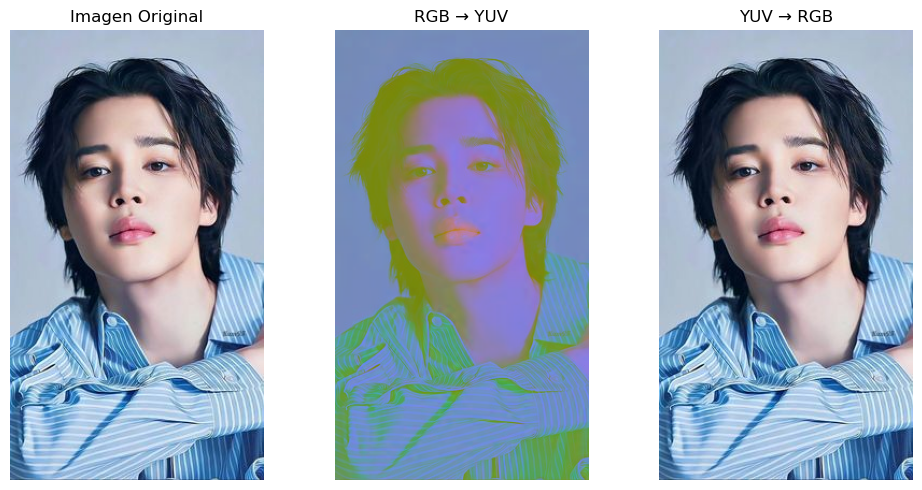

In [10]:
import cv2
import matplotlib.pyplot as plt

def convertir_color(imagen, tipo):

    if tipo == "RGB2YUV":
        return cv2.cvtColor(imagen, cv2.COLOR_BGR2YUV)

    elif tipo == "YUV2RGB":
        return cv2.cvtColor(imagen, cv2.COLOR_YUV2BGR)

    else:
        print("Tipo de conversión no válido")
        return imagen

imagen = cv2.imread("image.png")

imagen_yuv = convertir_color(imagen, "RGB2YUV")
imagen_rgb = convertir_color(imagen_yuv, "YUV2RGB")

plt.figure(figsize=(10,5))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.title("Imagen Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(imagen_yuv, cv2.COLOR_BGR2RGB))
plt.title("RGB → YUV")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(imagen_rgb, cv2.COLOR_BGR2RGB))
plt.title("YUV → RGB")
plt.axis("off")

plt.tight_layout()
plt.show()


Se une todo

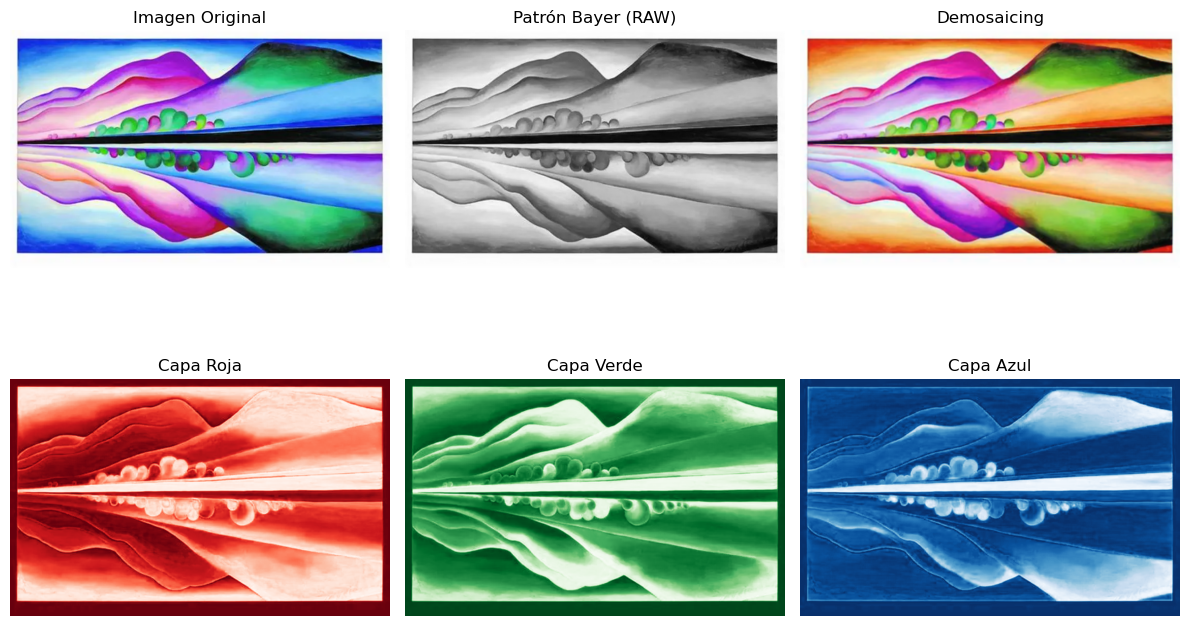

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


# Crear mosaico Bayer RGGB

def crear_mosaico_bayer(img):

    alto, ancho, _ = img.shape
    mosaico = np.zeros((alto, ancho), dtype=np.uint8)

    B, G, R = cv2.split(img)

    for i in range(alto):
        for j in range(ancho):

            if i % 2 == 0 and j % 2 == 0:   # Rojo
                mosaico[i,j] = R[i,j]

            elif i % 2 == 0 and j % 2 == 1: # Verde
                mosaico[i,j] = G[i,j]

            elif i % 2 == 1 and j % 2 == 0: # Verde
                mosaico[i,j] = G[i,j]

            else:                           # Azul
                mosaico[i,j] = B[i,j]

    return mosaico

# Reconstrucciion de color

def demosaicing(mosaico):

    return cv2.cvtColor(mosaico, cv2.COLOR_BAYER_RG2BGR)


# Mostrar capas RGB
def mostrar_capas(img):

    B, G, R = cv2.split(img)

    return R, G, B

# PROGRAMA PRINCIPAL


imagen = cv2.imread("img3.png")

# generar mosaico Bayer
mosaico = crear_mosaico_bayer(imagen)

# reconstruir imagen
reconstruida = demosaicing(mosaico)

# obtener capas
R, G, B = mostrar_capas(imagen)

# Visualizacion

plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.title("Imagen Original")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(mosaico, cmap="gray")
plt.title("Patrón Bayer (RAW)")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(cv2.cvtColor(reconstruida, cv2.COLOR_BGR2RGB))
plt.title("Demosaicing")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(R, cmap="Reds")
plt.title("Capa Roja")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(G, cmap="Greens")
plt.title("Capa Verde")
plt.axis("off")

plt.subplot(2,3,6)
plt.imshow(B, cmap="Blues")
plt.title("Capa Azul")
plt.axis("off")

plt.tight_layout()
plt.show()


mejorado aplicando todo

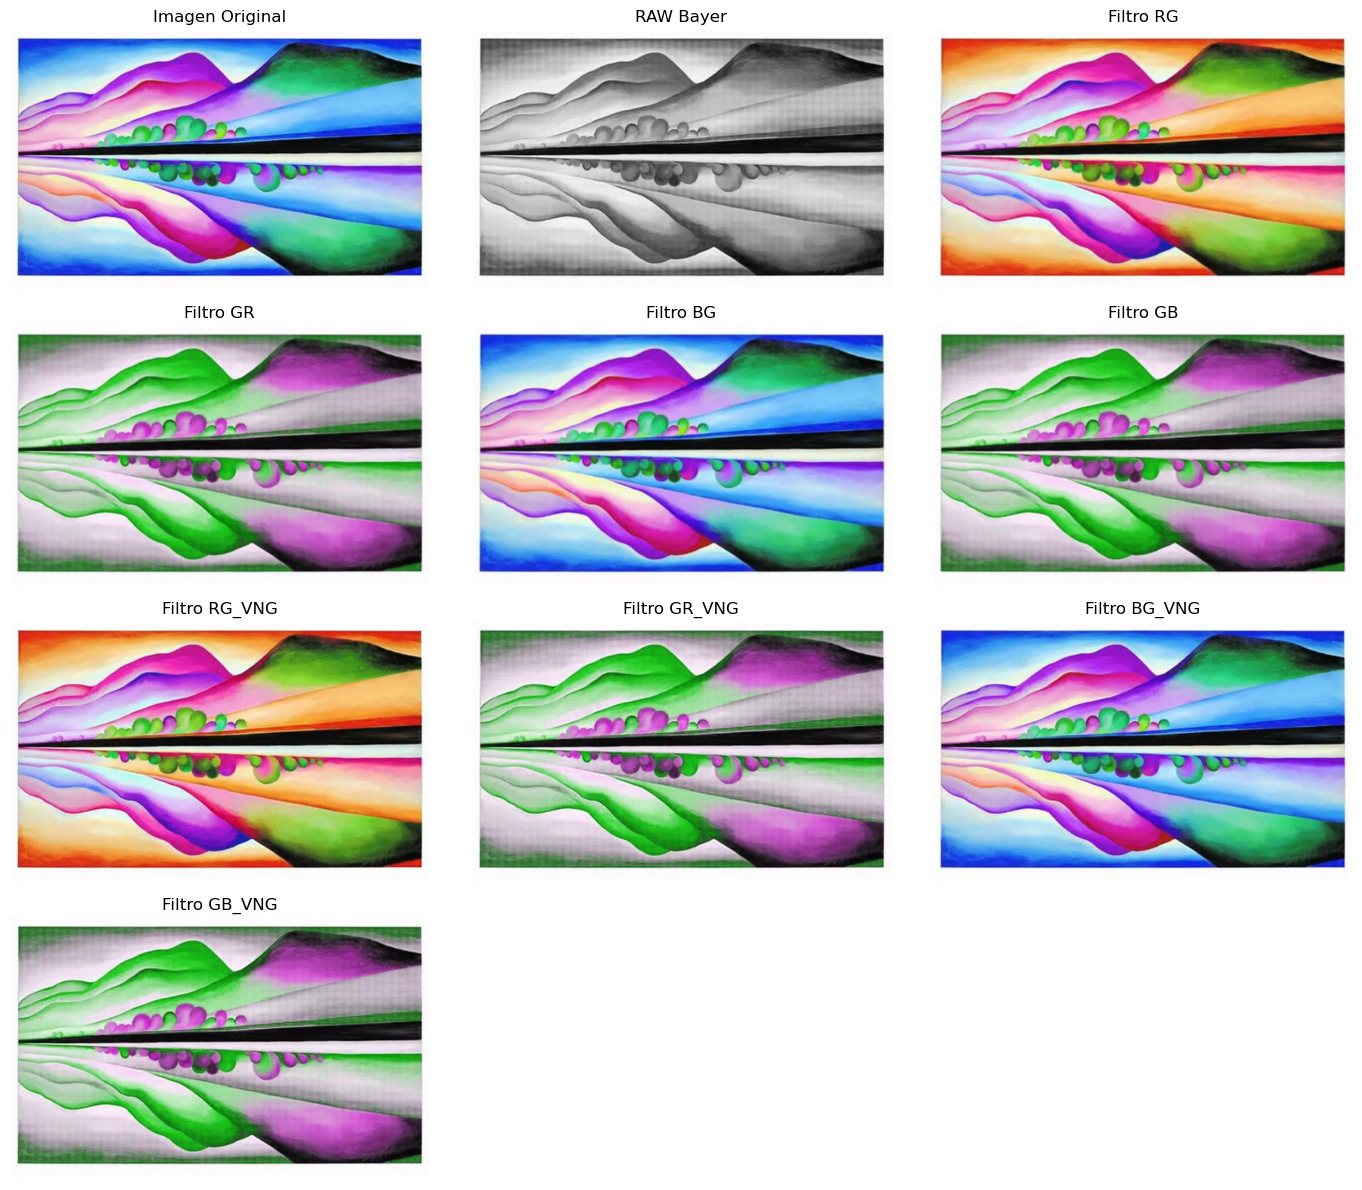

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def crear_mosaico_bayer(img):

    h, w, _ = img.shape
    mosaico = np.zeros((h, w), dtype=np.uint8)

    B, G, R = cv2.split(img)

    for i in range(h):
        for j in range(w):

            # Patrón RGGB
            if i % 2 == 0 and j % 2 == 0:
                mosaico[i, j] = R[i, j]

            elif i % 2 == 0 and j % 2 == 1:
                mosaico[i, j] = G[i, j]

            elif i % 2 == 1 and j % 2 == 0:
                mosaico[i, j] = G[i, j]

            else:
                mosaico[i, j] = B[i, j]

    return mosaico


def aplicar_filtros_bayer(mosaico):

    filtros = {
        "RG": cv2.COLOR_BAYER_RG2BGR,
        "GR": cv2.COLOR_BAYER_GR2BGR,
        "BG": cv2.COLOR_BAYER_BG2BGR,
        "GB": cv2.COLOR_BAYER_GB2BGR,
        "RG_VNG": cv2.COLOR_BAYER_RG2BGR_VNG,
        "GR_VNG": cv2.COLOR_BAYER_GR2BGR_VNG,
        "BG_VNG": cv2.COLOR_BAYER_BG2BGR_VNG,
        "GB_VNG": cv2.COLOR_BAYER_GB2BGR_VNG
    }

    resultados = {}

    for nombre, filtro in filtros.items():
        resultados[nombre] = cv2.cvtColor(mosaico, filtro)

    return resultados

def mostrar_imagenes(original, mosaico, resultados):

    plt.figure(figsize=(14,12))

    plt.subplot(4,3,1)
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.title("Imagen Original")
    plt.axis("off")

    plt.subplot(4,3,2)
    plt.imshow(mosaico, cmap="gray")
    plt.title("RAW Bayer")
    plt.axis("off")

    for i, (nombre, img) in enumerate(resultados.items()):
        plt.subplot(4,3,i+3)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title("Filtro " + nombre)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


imagen = cv2.imread("img3.png")
mosaico = crear_mosaico_bayer(imagen)
resultados = aplicar_filtros_bayer(mosaico)

mostrar_imagenes(imagen, mosaico, resultados)
